# Example 1 of integrating Stata and Python notebook

In [16]:
import stata_setup
import pandas as pd
import numpy as np

stata_setup.config(r"C:\Program Files\Stata18", "mp")


The [stata](https://www.stata.com/python/pystata18/notebook/Magic%20Commands1.html) magic is used to execute Stata commands in an IPython environment. In a notebook cell, we put Stata commands underneath the **%%stata** cell magic to direct the cell to call Stata. The Stata output is displayed underneath the cell.

In [3]:
%%stata
capture log close
log using mus03p1reg.txt, text replace

********** OVERVIEW OF mus03p1reg.do **********

* STATA Program 
* copyright C 2008 by A. Colin Cameron and Pravin K. Trivedi 
* used for "Microeconometrics using Stata" 
* by A. Colin Cameron and Pravin K. Trivedi (2008)
* Stata Press

* Chapter 3
* 3.2: DATA: SUMMARY STATISTICS
* 3.4: BASIC REGRESSION ANALYSIS
* 3.5: SPECIFICATION ANALYSIS
* 3.6: PREDICTION
* 3.7: SAMPLING WEIGHTS
* 3.8: OLS USING MATA

* To run you need files
*   mus03data.dta 
* in your directory
* Stata user-written commands 
*    esttab
*    estadd
* are used

********** SETUP **********

set more off
version 10.1
clear all
set mem 10m
set linesize 82
set scheme s1mono  /* Graphics scheme */

********** DATA DESCRIPTION **********

* File mus03data is extract from MEPS

************ 3.2: DATA SUMMARY STATISTICS

* Variable description for medical expenditure dataset
use mus03data.dta
describe totexp ltotexp posexp suppins phylim actlim totchr age female income



. capture log close

. log using mus03p1reg.txt, text replace
(file
    c:\Users\tonio\OneDrive\Documenti\GitHub\toniopap.github.io\mus03p1reg.tx
    > t not found)
-------------------------------------------------------------------------------
      name:  <unnamed>
       log:  c:\Users\tonio\OneDrive\Documenti\GitHub\toniopap.github.io\mus03p
> 1reg.txt
  log type:  text
 opened on:   1 Apr 2025, 11:53:55

. 
. ********** OVERVIEW OF mus03p1reg.do **********
. 
. * STATA Program 
. * copyright C 2008 by A. Colin Cameron and Pravin K. Trivedi 
. * used for "Microeconometrics using Stata" 
. * by A. Colin Cameron and Pravin K. Trivedi (2008)
. * Stata Press
. 
. * Chapter 3
. * 3.2: DATA: SUMMARY STATISTICS
. * 3.4: BASIC REGRESSION ANALYSIS
. * 3.5: SPECIFICATION ANALYSIS
. * 3.6: PREDICTION
. * 3.7: SAMPLING WEIGHTS
. * 3.8: OLS USING MATA
. 
. * To run you need files
. *   mus03data.dta 
. * in your directory
. * Stata user-written commands 
. *    esttab
. *    estadd
. * are use

In [4]:
%%stata
* Summary statistics for medical expenditure dataset
summarize totexp ltotexp posexp suppins phylim actlim totchr age female income


. * Summary statistics for medical expenditure dataset
. summarize totexp ltotexp posexp suppins phylim actlim totchr age female income

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
      totexp |      3,064    7030.889    11852.75          0     125610
     ltotexp |      2,955    8.059866    1.367592   1.098612   11.74094
      posexp |      3,064    .9644256    .1852568          0          1
     suppins |      3,064    .5812663    .4934321          0          1
      phylim |      3,064    .4255875    .4945125          0          1
-------------+---------------------------------------------------------
      actlim |      3,064    .2836162    .4508263          0          1
      totchr |      3,064    1.754243    1.307197          0          7
         age |      3,064    74.17167    6.372938         65         90
      female |      3,064    .5796345    .4936982          0          

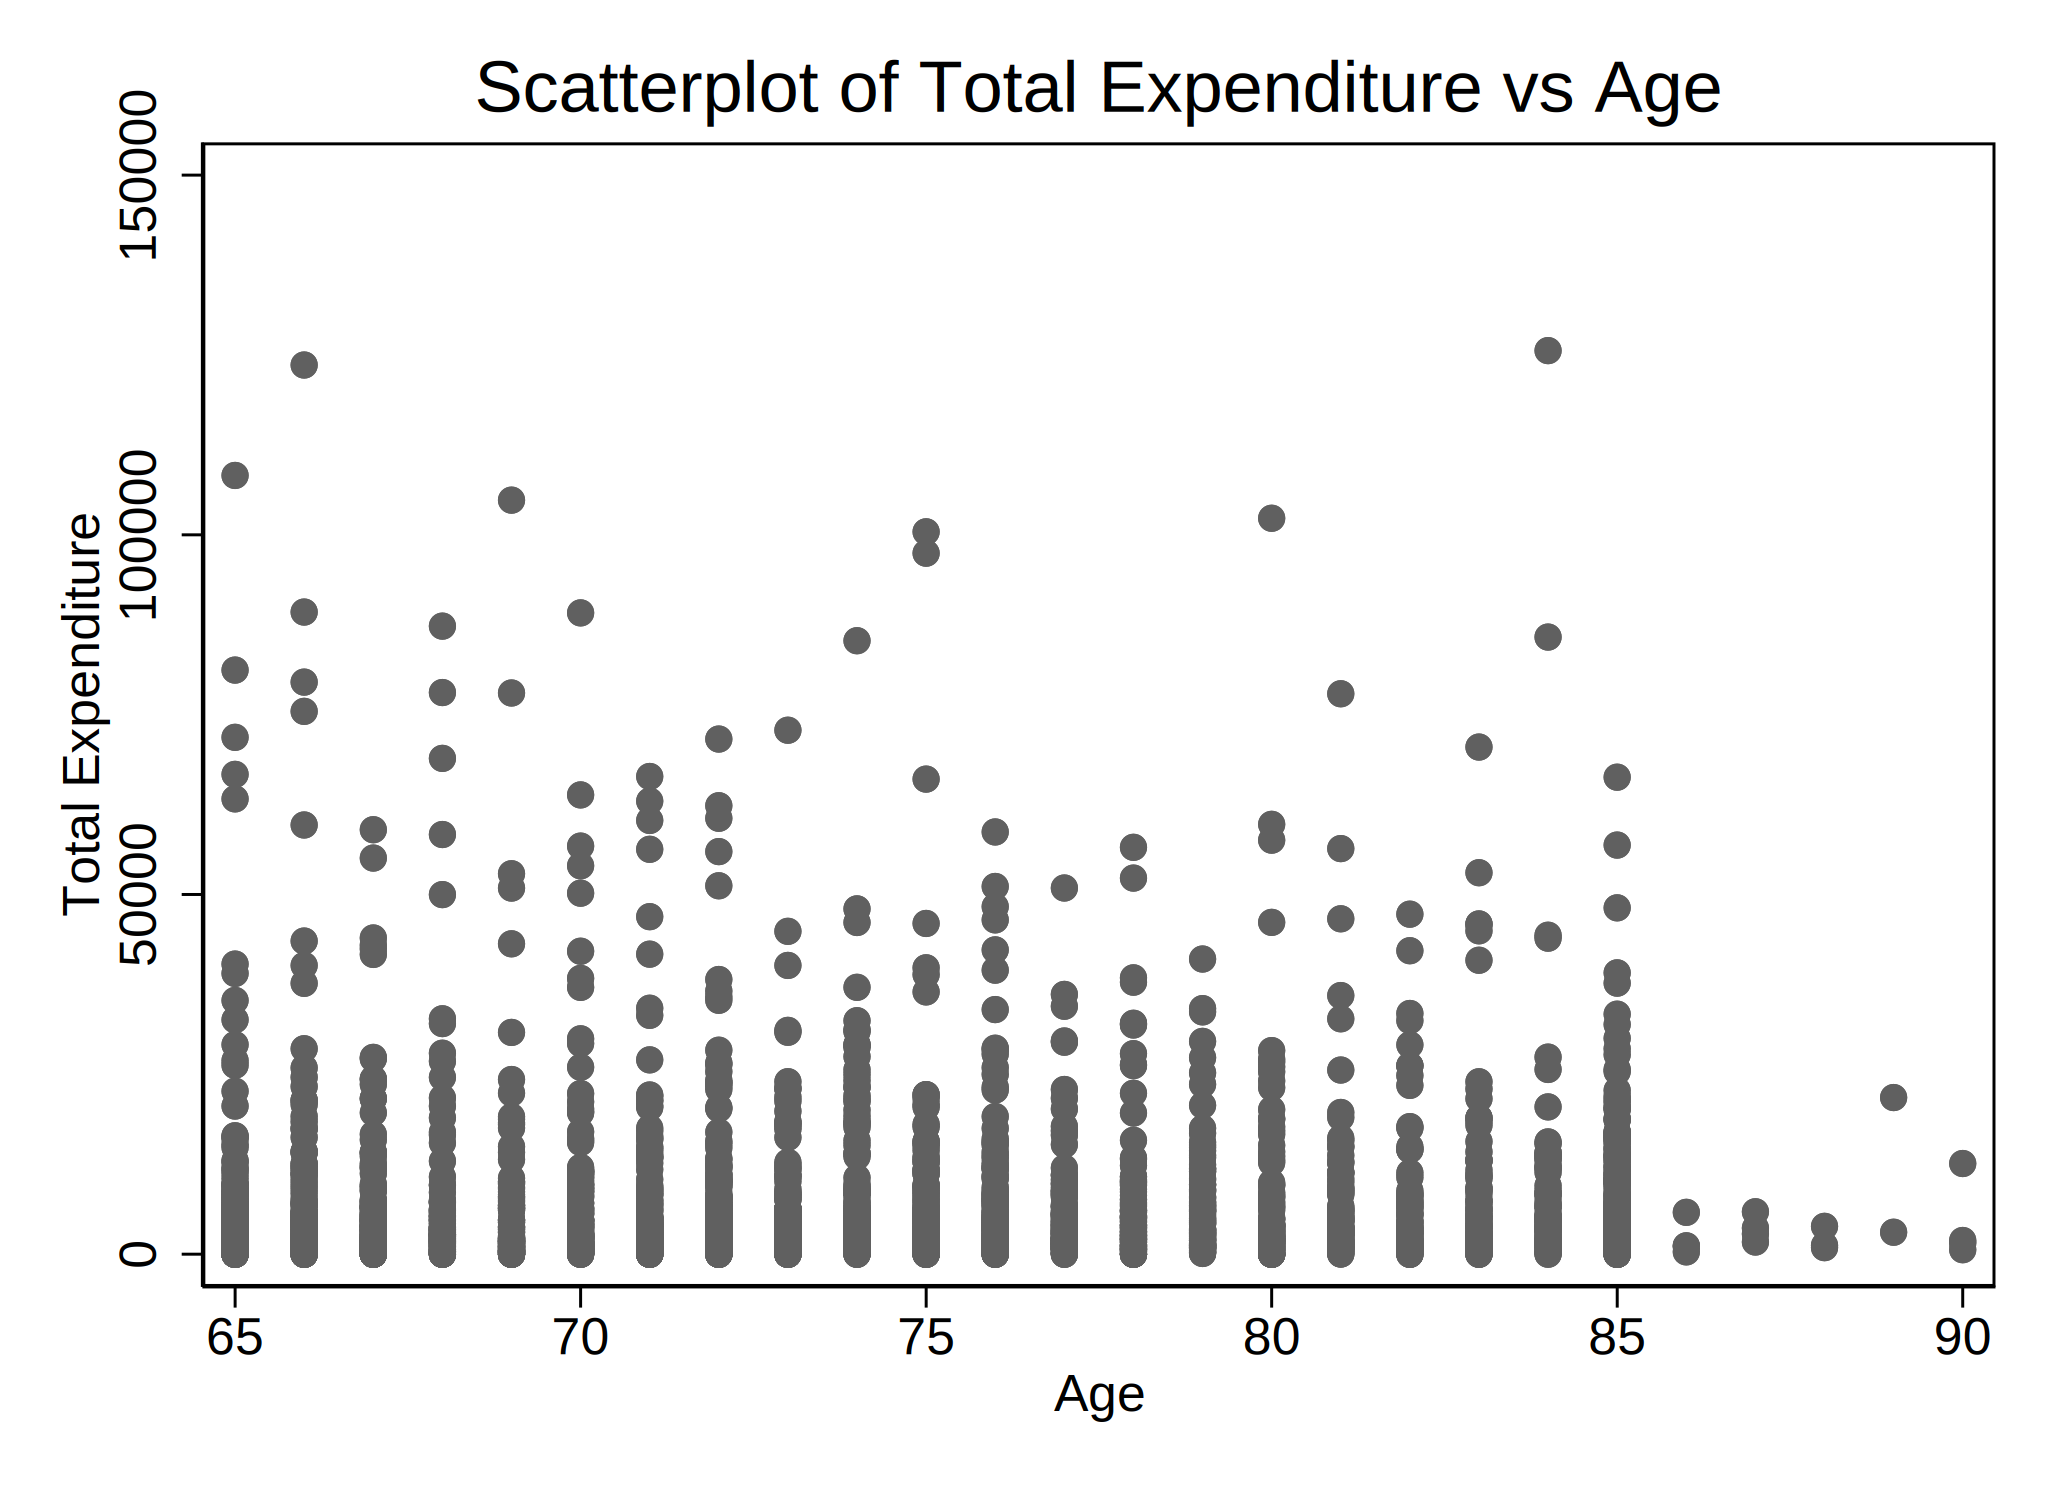

In [8]:
%%stata
scatter totexp age, ytitle("Total Expenditure") xtitle("Age") title("Scatterplot of Total Expenditure vs Age")

## Example 2 of integrating Stata and Python Notebook

Next, we load Python data into Stata, perform analyses in Stata, and then pass Stata returned results to Python for further analysis, using the same database. This is a ***markdown*** usage examples

We use [pandas](https://pandas.pydata.org/) method **read_csv()** to read the data from the .csv file into a [pandas](https://pandas.pydata.org/) dataframe named mus03data.


In [9]:
df = pd.read_csv("mus03data.csv")
df.head()

,dupersid,year03,age,famsze,educyr,totexp,private,retire,female,white,...,hmo,mnc,ratio,posexp,suppins,hvgg,hfp,ltotexp,hins,hdem
0,93193020,1,69,2,14,3,1,1,0,1,...,0,0,0.0,1,1,1,0,1.098612,1.0,NaN
1,72072017,1,65,1,11,6,1,0,1,1,...,0,0,0.0,1,1,1,0,1.791759,NaN,1.0
2,25296013,1,85,1,14,9,0,0,1,1,...,0,0,0.0,1,0,1,0,2.197225,NaN,1.0
3,23628011,1,76,5,10,14,0,0,1,1,...,0,0,0.0,1,0,1,0,2.639057,1.0,1.0
4,95041014,1,71,1,14,18,0,1,1,1,...,0,0,0.0,1,0,1,0,2.890372,1.0,1.0


We load the dataframe into Stata by specifying the [-d](https://www.stata.com/python/pystata18/notebook/Magic%20Commands1.html#-d-DATA) argument of the **%%stata** magic, and then within Stata, we fit a logistic regression model using **ltotexp suppins phylim actlim totchr age female income**. We also push Stata's estimation results displayed by ereturn list, including the coefficient vector **e(b)** and variance–covariance matrix **e(V)**, into a Python dictionary called *myereturnlist* by specifying the [-eret](https://www.stata.com/python/pystata18/notebook/Magic%20Commands1.html#Arguments) argument.

In [10]:
%%stata -d df -eret myereturnlist
reg ltotexp suppins phylim actlim totchr age female income
ereturn list


. reg ltotexp suppins phylim actlim totchr age female income

      Source |       SS           df       MS      Number of obs   =     2,955
-------------+----------------------------------   F(7, 2947)      =    124.98
       Model |  1264.72124         7  180.674463   Prob > F        =    0.0000
    Residual |  4260.16814     2,947  1.44559489   R-squared       =    0.2289
-------------+----------------------------------   Adj R-squared   =    0.2271
       Total |  5524.88938     2,954  1.87030785   Root MSE        =    1.2023

------------------------------------------------------------------------------
     ltotexp | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
     suppins |   .2556428   .0462264     5.53   0.000     .1650034    .3462821
      phylim |   .3020598   .0569709     5.30   0.000      .190353    .4137666
      actlim |   .3560054   .0621118     5.73   0.000     .2342185 

We can access e(b) and e(V) by typing myereturnlist['e(b)'] and myereturnlist['e(V)'], respectively, in Python. They are stored in [NumPy](https://numpy.org/) arrays.

In [11]:
myereturnlist['e(b)'], myereturnlist['e(V)']

(array([[ 2.55642758e-01,  3.02059795e-01,  3.56005402e-01,
          3.75820142e-01,  3.80162916e-03, -8.43275213e-02,
          2.54981756e-03,  6.70373746e+00]]),
 array([[ 2.13688144e-03, -9.17805426e-05,  1.30083658e-04,
         -3.38236613e-05,  1.53414267e-05,  1.13633996e-04,
         -8.03686602e-06, -2.22339501e-03],
        [-9.17805426e-05,  3.24568474e-03, -1.81719131e-03,
         -1.89562923e-04, -2.92727831e-05, -1.71959058e-04,
          4.71588283e-07,  1.76781099e-03],
        [ 1.30083658e-04, -1.81719131e-03,  3.85787260e-03,
         -1.93424897e-04, -2.28917540e-05,  8.52236462e-05,
          4.70117622e-06,  1.49776690e-03],
        [-3.38236613e-05, -1.89562923e-04, -1.93424897e-04,
          3.39396819e-04,  9.74758323e-07, -2.25023378e-05,
          6.56491091e-07, -5.29618813e-04],
        [ 1.53414267e-05, -2.92727831e-05, -2.28917540e-05,
          9.74758323e-07,  1.33672613e-05, -6.30158403e-06,
          3.61490252e-07, -9.88452720e-04],
        [ 1.13

In [18]:
df.describe()

,dupersid,year03,age,famsze,educyr,totexp,private,retire,female,white,...,hmo,mnc,ratio,posexp,suppins,hvgg,hfp,ltotexp,hins,hdem
count,3.064000e+03,3064.0,3064.000000,3064.000000,3064.000000,3064.000000,3064.000000,3064.000000,3064.000000,3064.000000,...,3064.000000,3064.000000,3064.000000,3064.000000,3064.000000,3064.000000,3064.000000,2955.000000,1506.0,1737.0
mean,6.241623e+07,1.0,74.171671,1.907963,11.775457,7030.889360,0.581266,0.594648,0.579634,0.974217,...,0.115862,0.019256,0.012095,0.964426,0.581266,0.605418,0.207898,8.059866,1.0,1.0
std,3.433003e+07,0.0,6.372938,0.988350,3.435878,11852.751889,0.493432,0.491040,0.493698,0.158514,...,0.320111,0.137445,0.095816,0.185257,0.493432,0.488841,0.421651,1.367592,0.0,0.0
min,2.000402e+07,1.0,65.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.098612,1.0,1.0
25%,2.440302e+07,1.0,69.000000,1.000000,10.000000,1272.500000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,7.267525,1.0,1.0
50%,9.008002e+07,1.0,73.000000,2.000000,12.000000,3134.500000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,8.111928,1.0,1.0
75%,9.418003e+07,1.0,79.000000,2.000000,14.000000,7142.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,8.921524,1.0,1.0
max,9.834702e+07,1.0,90.000000,13.000000,17.000000,125610.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,11.740937,1.0,1.0
